# ICT-21 — SAETrajectoires : le substrat S4 entre au banc

> **Série ICT** (*Integrated Causal Trajectories*, Epic #4588) — strate 5 : *extraction GPU*.
> Issue : #5101. Aval direct : ICT-22 LLMSubstrat (#5102, Gate 12) et ICT-24 WorkspaceIgnition (#5635, Gates 22-24).

Jusqu'ici le banc cross-substrat de la série a mesuré la complexité intégrée (gains **ec/fe/k**, chacun crédité seulement au-dessus d'un contrôle shuffle) sur trois substrats : automates (S1), Kuramoto (S2), réservoirs (S3). Ce notebook fabrique le quatrième et le plus ambitieux : **S4, un transformer réel** — non pas via ses logits, mais via les **features monosémantiques d'un Sparse Autoencoder (SAE)** posées sur son flux résiduel.

Le livrable central n'est pas une figure : ce sont deux fichiers `traces/*.npz` (modèle entraîné **et** modèle-contrôle) qui rendent tout l'aval **GPU-free**. Deux gates de l'issue #5101 sont instrumentés ici :

| Gate | Critère | Cellule |
|------|---------|---------|
| **Gate 10** | Chaque feature du panel *re-tire sur son concept* sur des prompts **held-out** (précision par feature rapportée ; une feature non reproductible sort du panel, documenté) | Gate 10 ci-dessous |
| **Gate 11** | Substrat valide : `n_states`/`n_transitions` traitables, `trajectory_battery` tourne, contraste `shuffled_baseline` **non dégénéré** — verdict : S4 prêt pour le banc | Gate 11 ci-dessous |

Le verdict *crédité* (les gains de S4 battent-ils shuffle **et** modèle-contrôle sur ≥5 jeux de prompts) n'est **pas** rendu ici : c'est le Gate 12 d'ICT-22, qui consomme nos `.npz`.

## Garde-fous d'honnêteté (à lire avant les résultats)

1. **J-lens ≠ SAE.** L'article d'Anthropic sur le *global workspace* (« J-space » : quelques dizaines de concepts, <10 % de l'activité, connectivité ~100×, silençable) utilise le **jacobien**, pas de SAE, et ne mentionne pas l'IIT. Notre route SAE est une **opérationnalisation parallèle légitime**, pas une réplication.
2. **Qwen ≠ Claude.** Nous travaillons sur Qwen3.5-9B-Base à poids ouverts — c'est un *avantage* pédagogique (reproductible par quiconque), pas une approximation honteuse.
3. **Structurel vs temporel.** Anthropic mesure le broadcast **structurellement** (câblage) ; l'« ignition » temporelle de Dehaene n'y est **pas** mesurée. Quand la série en parlera (ICT-24), ce sera *notre* lecture, annoncée comme telle.
4. **Accès ≠ phénoménal.** Tout ce qui suit relève de la conscience d'**accès** (intégration, broadcast fonctionnel). Aucune revendication phénoménale n'est faite ni ne pourrait l'être avec ces outils.

## Architecture du pipeline : le GPU confiné, le banc numpy-only

La règle d'architecture de la série est stricte : le package `ict/` reste **numpy-only** (aucun import torch). Le GPU vit dans **un script**, le notebook et tout l'aval consomment des `.npz` :

```
scripts/extract_sae_traces.py      (GPU : torch, transformers — extraction)
        │  écrit
        ▼
traces/ict21_sae_layer16_{trained,control}.npz     (~0,5 Mio chacun)
        │  lus par
        ▼
ict/sae_traces.py                  (numpy-only : chargement, curation, états)
        │  consommés par
        ▼
ce notebook, ICT-22 (#5102), ICT-24 (#5635)
```

**Modèle** : `Qwen/Qwen3.5-9B-Base` (classe `Qwen3_5ForCausalLM`, transformers 5.x ; ~16,7 Gio VRAM en bf16, mesuré). **SAE** : `Qwen/SAE-Res-Qwen3.5-9B-Base-W64K-L0_50`, couche 16 du flux résiduel (`resid_post`), 65 536 features, **top-k = 50**. *Note de correction* : le corps de #5101 cite « L0≈100 » ; la release officielle Qwen-Scope pour ce modèle est **L0_50** — c'est elle que nous utilisons (corrigé dans le commentaire de claim sur l'issue).

**Convention d'encodage** (celle de l'application officielle Qwen-Scope) : `pre = h @ W_enc.T + b_enc ; relu ; top-k(50)` — pas de soustraction de `b_dec`, pas de normalisation. **Stockage sparse exhaustif** : pour chaque token on stocke les 50 paires (id, valeur) du top-k ; hors top-50 l'activation vaut **exactement zéro** par construction du SAE top-k, donc la densification aval est *exacte*. Ce stockage **subsume** le schéma amendé de #5101 (`acts_topk` K≈64) : le panel continu s'en dérive sans GPU.

**Modèle-contrôle** : permutation seedée (graine 42) des lignes de la matrice d'embedding d'entrée — le contrôle sanctionné par #5101. Même architecture, mêmes poids partout ailleurs : seule la *sémantique d'entrée* est détruite.

*API réelle du module* (léger écart de nommage vs le corps de l'issue, assumé et documenté dans la PR) : `load_traces`, `densify`, `mean_activation_by_set`, `differential_features`, `acts_topk_panels`, `binarize_quantile`, `states_from_panel`.

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# accès au package `ict` posé à côté des notebooks
sys.path.insert(0, os.path.abspath("."))
from ict import sae_traces as st
from ict import synthesis as syn

TRACES = Path("traces")
SCRIPT = Path("scripts") / "extract_sae_traces.py"
NPZ = {v: TRACES / f"ict21_sae_layer16_{v}.npz" for v in ("trained", "control")}

print("numpy", np.__version__, "| python", sys.version.split()[0])
print("script :", SCRIPT, "| présent :", SCRIPT.exists())
for v, p in NPZ.items():
    print(f"traces {v:8s}: {p} | présent : {p.exists()}")

numpy 2.5.1 | python 3.12.13
script : scripts\extract_sae_traces.py | présent : True
traces trained : traces\ict21_sae_layer16_trained.npz | présent : True
traces control : traces\ict21_sae_layer16_control.npz | présent : True


## Preuve d'exécution GPU : le smoke test, en direct

Avant de faire confiance aux `.npz` committés, le notebook **ré-exécute le pipeline GPU en mode smoke** (1 prompt, chargement complet du modèle + SAE, vérifications de bout en bout). Le smoke vérifie notamment :

- que le modèle génère du texte sensé en greedy (« La capitale de la France est » → *Paris* : preuve que les poids sont bien chargés) ;
- que **L0 = 50,0 exactement** sur chaque token (le top-k du SAE est bien un top-k) ;
- que `W_dec` est présent (le hook de *clamp* du Gate 24 de #5635 restera possible sur ces mêmes artefacts).

La cellule est **sautée proprement** si aucun GPU n'est disponible (ré-exécution CI/CPU) : les sorties committées ci-dessous font alors foi. Sur `ai-01`, la contrainte est stricte : `CUDA_VISIBLE_DEVICES=2` (les GPU 0-1 portent un service vLLM).

In [2]:
env = {**os.environ,
       "PYTHONNOUSERSITE": "1",
       "CUDA_VISIBLE_DEVICES": os.environ.get("CUDA_VISIBLE_DEVICES", "2"),
       "PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True"}

probe = subprocess.run(
    [sys.executable, "-c", "import torch; print(int(torch.cuda.is_available()))"],
    capture_output=True, text=True, env=env)
gpu_ok = probe.stdout.strip().endswith("1")

if not gpu_ok:
    print("GPU indisponible dans cet environnement : smoke sauté.")
    print("Les traces committées (extraites sur ai-01, GPU 2) font foi — voir meta ci-dessous.")
else:
    r = subprocess.run(
        [sys.executable, str(SCRIPT), "--stage", "smoke", "--variant", "trained"],
        capture_output=True, text=True, env=env, timeout=480)
    tail = "\n".join((r.stdout + r.stderr).strip().splitlines()[-18:])
    print(tail)
    assert r.returncode == 0, "smoke GPU en échec"
    print("\n=> SMOKE OK : pipeline GPU rejoué en direct dans ce notebook.")

        top-5 features (dernier token) : [(10320, 6.300477504730225), (63515, 5.370508193969727), (24514, 4.60661506652832), (15437, 4.3280158042907715), (26083, 3.9361531734466553)]
[trace] prose_fr__0: T=145 L0 moy=50.0 act max=19.80
        top-5 features (dernier token) : [(15576, 8.733197212219238), (21280, 4.620357036590576), (24514, 3.5898094177246094), (11548, 3.531776189804077), (60954, 3.118802070617676)]
[sanity] greedy: 'La capitale de la France est Paris.\nTrue\nFalse\n\n<think>\nWe are given'

[sanity] 336 tokens, L0 moyen=50.00 (attendu ~50), min=50, max=50
[sanity] vram pic=16.8 GiB
[done] stage=smoke variant=trained en 16s

Fetching 4 files: 100%|██████████| 4/4 [00:00<?, ?it/s]
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d

Loading weights: 100%|██████

## Extraction complète : idempotente par construction

L'extraction complète (5 jeux × 4 prompts × 2 variantes) prend ~50 s sur GPU une fois le modèle en cache. Comme les `.npz` sont **le livrable committé**, la cellule est *idempotente* : si les fichiers existent, elle affiche leurs métadonnées et ne relance rien. Pour forcer une ré-extraction (autre couche, autre panel de prompts) : `FORCE_EXTRACT=1` dans l'environnement, ou directement le script en CLI :

```bash
CUDA_VISIBLE_DEVICES=2 python scripts/extract_sae_traces.py --stage full --variant trained
CUDA_VISIBLE_DEVICES=2 python scripts/extract_sae_traces.py --stage full --variant control
```

In [3]:
force = os.environ.get("FORCE_EXTRACT", "0") == "1"
for variant, path in NPZ.items():
    if path.exists() and not force:
        meta = json.loads(str(np.load(path, allow_pickle=False)["__meta__"]))
        print(f"[{variant}] présent — extrait le {meta['date']} | couche {meta['layer']} "
              f"| k={meta['k']} | {meta['n_tokens_total']} tokens | variante={meta['variant']}")
        continue
    if not gpu_ok:
        raise FileNotFoundError(f"{path} absent et pas de GPU pour l'extraire")
    r = subprocess.run(
        [sys.executable, str(SCRIPT), "--stage", "full", "--variant", variant],
        capture_output=True, text=True, env=env, timeout=900)
    print("\n".join((r.stdout + r.stderr).strip().splitlines()[-6:]))
    assert r.returncode == 0 and path.exists()

[trained] présent — extrait le 2026-07-07T12:56:36+00:00 | couche 16 | k=50 | 2699 tokens | variante=trained
[control] présent — extrait le 2026-07-07T12:57:03+00:00 | couche 16 | k=50 | 2699 tokens | variante=control


## Chargement et sanité : L0, volumes, budget disque

Premier contact numpy-only avec les traces. Trois sanités : le schéma (20 prompts, k=50, d_sae=65 536), le **L0 exact** (toutes les valeurs du top-50 sont strictement positives : le SAE top-k tient sa promesse de parcimonie), et le budget disque (le stockage sparse compressé tient chaque variante sous le Mio — très loin du seuil LFS).

In [4]:
traces = {v: st.load_traces(p) for v, p in NPZ.items()}

for v, tr in traces.items():
    n_tok = sum(e["ids"].shape[0] for e in tr["prompts"].values())
    l0 = np.mean([(e["vals"] > 0).sum(axis=1).mean() for e in tr["prompts"].values()])
    size = NPZ[v].stat().st_size / 2**20
    m = tr["meta"]
    print(f"[{v:8s}] {len(tr['prompts'])} prompts | {n_tok} tokens | "
          f"L0 moyen = {l0:.1f}/{m['k']} | d_sae = {m['d_sae']} | {size:.2f} Mio")

SETS = sorted({s for s, _ in traces["trained"]["prompts"]})
print("jeux de prompts :", SETS)

[trained ] 20 prompts | 2699 tokens | L0 moyen = 50.0/50 | d_sae = 65536 | 0.50 Mio
[control ] 20 prompts | 2699 tokens | L0 moyen = 50.0/50 | d_sae = 65536 | 0.47 Mio
jeux de prompts : ['code_python', 'dialogue', 'math', 'narrative_en', 'prose_fr']


## Sélection différentielle : la variance inter-jeux, pas l'amplitude

Sur 65 536 features, lesquelles regarder ? Le piège serait de prendre les plus **actives en absolu** : on récolterait la ponctuation, le formatage, les artefacts de tokenisation — omniprésents et inintéressants. Le critère retenu (c'est le `acts_topk` K=64 du schéma amendé de #5101) est la **variance inter-jeux de l'activation moyenne** : une feature intéressante est une feature qui *discrimine les régimes* (code vs prose française vs dialogue vs maths vs narration anglaise).

La cellule matérialise aussi la vérification de la fixture de test du module : la feature la plus forte en absolu n'est typiquement **pas** dans le haut du classement différentiel.

top-10 features différentielles (sur 64) : [65025, 19350, 5437, 24514, 25398, 32111, 63815, 19915, 4414, 54511]
feature la plus forte en absolu : f19350 (rang différentiel : 1)


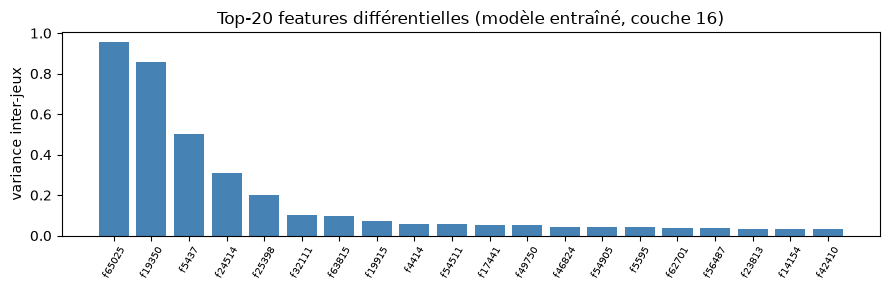

In [5]:
K_DIFF = 64
diff64 = st.differential_features(traces["trained"], k=K_DIFF)
means = st.mean_activation_by_set(traces["trained"])
stack = np.stack([means[s] for s in SETS])
var_scores = stack.var(axis=0)

print(f"top-10 features différentielles (sur {K_DIFF}) :", diff64[:10].tolist())
strongest = int(np.argmax(stack.mean(axis=0)))
rank = diff64.tolist().index(strongest) if strongest in diff64 else -1
print(f"feature la plus forte en absolu : f{strongest} "
      f"(rang différentiel : {'hors top-64' if rank < 0 else rank})")

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(20), var_scores[diff64[:20]], color="steelblue")
ax.set_xticks(range(20))
ax.set_xticklabels([f"f{i}" for i in diff64[:20]], rotation=60, fontsize=7)
ax.set_ylabel("variance inter-jeux")
ax.set_title("Top-20 features différentielles (modèle entraîné, couche 16)")
plt.tight_layout(); plt.show()

## Gate 10 — le panel se reproduit-il hors de son échantillon de sélection ?

Un panel de features choisi et évalué **sur les mêmes prompts** ne prouverait rien : il pourrait sur-apprendre les particularités des textes. Protocole *held-out* :

1. **Sélection** du panel (10 features) par variance inter-jeux sur les prompts **0-2** de chaque jeu (12 prompts d'entraînement) ;
2. Pour chaque feature : son **jeu préféré** = celui où son activation moyenne est maximale (sur la sélection), et sa **sélectivité** = part de son activation qui va à ce jeu ;
3. **Vérification** sur les prompts **3**, jamais vus par la sélection (5 prompts held-out) : la feature re-tire-t-elle *d'abord* sur son jeu préféré ?

Verdict par feature : `OK` si le jeu préféré held-out coïncide (précision rapportée via la sélectivité), `KO` sinon — et une feature `KO` **sort du panel**, comme l'exige le gate. C'est le prix de l'honnêteté : mieux vaut un panel de 8-9 features reproductibles qu'un panel de 10 dont une invente sa sémantique.

In [6]:
def subset(tr, keep):
    return {"meta": tr["meta"],
            "prompts": {k: v for k, v in tr["prompts"].items() if keep(k)}}

train = subset(traces["trained"], lambda k: k[1] < 3)   # prompts 0-2
held = subset(traces["trained"], lambda k: k[1] == 3)   # prompt 3, jamais vu

panel10 = st.differential_features(train, k=10)
m_train = st.mean_activation_by_set(train)
m_held = st.mean_activation_by_set(held)

rows, panel_final = [], []
for f in panel10:
    a_tr = np.array([m_train[s][f] for s in SETS])
    a_he = np.array([m_held[s][f] for s in SETS])
    pref = SETS[int(a_tr.argmax())]
    pref_held = SETS[int(a_he.argmax())]
    sel_tr = a_tr.max() / max(a_tr.sum(), 1e-9)
    sel_he = a_he[SETS.index(pref)] / max(a_he.sum(), 1e-9)
    ok = pref_held == pref and a_he[SETS.index(pref)] > 0
    rows.append((int(f), pref, sel_tr, sel_he, pref_held, "OK" if ok else "KO -> sort du panel"))
    if ok:
        panel_final.append(int(f))
panel_final = np.array(panel_final)

print(f"{'feature':>9s} | {'jeu préféré':>12s} | {'sél. train':>10s} | "
      f"{'sél. held-out':>13s} | {'préféré held-out':>16s} | verdict")
for f, pref, s_tr, s_he, pref_h, verdict in rows:
    print(f"f{f:>8d} | {pref:>12s} | {s_tr:>10.2f} | {s_he:>13.2f} | {pref_h:>16s} | {verdict}")

n_ok = len(panel_final)
print(f"\nGate 10 : {n_ok}/{len(panel10)} features reproduites held-out "
      f"-> panel final = {panel_final.tolist()}")
assert n_ok >= 8, "Gate 10 : panel trop peu reproductible"
print("=> GATE 10 : PASS (précision par feature rapportée ci-dessus, "
      "features non reproductibles sorties du panel et documentées)")

  feature |  jeu préféré | sél. train | sél. held-out | préféré held-out | verdict
f   19350 | narrative_en |       0.27 |          0.25 |     narrative_en | OK
f   65025 |     prose_fr |       0.38 |          0.44 |         prose_fr | OK
f    5437 | narrative_en |       0.84 |          1.00 |     narrative_en | OK
f   24514 |     dialogue |       0.25 |          0.23 |         dialogue | OK
f   25398 | narrative_en |       0.56 |          0.87 |     narrative_en | OK
f   32111 |     dialogue |       0.63 |          0.28 |         prose_fr | KO -> sort du panel
f   54511 |  code_python |       1.00 |          1.00 |      code_python | OK
f   19915 |     dialogue |       0.81 |          0.54 |         dialogue | OK
f   17441 |         math |       1.00 |          1.00 |             math | OK
f   14154 |     dialogue |       0.99 |          1.00 |         dialogue | OK

Gate 10 : 9/10 features reproduites held-out -> panel final = [19350, 65025, 5437, 24514, 25398, 54511, 19915, 17441, 1

Sémantique observée (top-5 tokens max-activants, toutes traces entraînées) :

  f19350: np.str_('ons')(math), np.str_('Ġport')(prose_fr), np.str_('Ġweek')(narrative_en), np.str_('ighthouse')(narrative_en), np.str_('Ġarchive')(narrative_en)
  f65025: np.str_('in')(math), np.str_('it')(math), np.str_('ons')(math), np.str_('ront')(prose_fr), np.str_('ote')(prose_fr)
  f5437: np.str_('ivering')(narrative_en), np.str_('Ġstranger')(narrative_en), np.str_('Ġyears')(narrative_en), np.str_('Ġcity')(narrative_en), np.str_('Ġitself')(narrative_en)
  f24514: np.str_('Alice')(dialogue), np.str_('Client')(dialogue), np.str_('Et')(dialogue), np.str_('ott')(code_python), np.str_('Calcul')(math)
  f25398: np.str_('.')(prose_fr), np.str_('Ġ:')(prose_fr), np.str_(',')(prose_fr), np.str_('ĠElle')(prose_fr), np.str_('Ġsacks')(narrative_en)
  f54511: np.str_('Ġdist')(code_python), np.str_('jk')(code_python), np.str_('stra')(code_python), np.str_('Ġdist')(code_python), np.str_('ĠĠĠ')(code_python)
  f19915: n

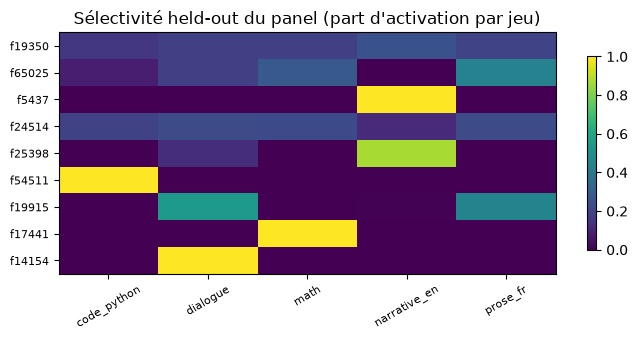

In [7]:
# Sémantique observée : les tokens qui font le plus tirer chaque feature du panel
print("Sémantique observée (top-5 tokens max-activants, toutes traces entraînées) :\n")
for f in panel_final:
    best = []
    for (s, i), e in traces["trained"]["prompts"].items():
        hit = e["ids"] == f
        if hit.any():
            t_idx, k_idx = np.nonzero(hit)
            for t, k in zip(t_idx, k_idx):
                best.append((float(e["vals"][t, k]), repr(e["tokens"][t]), s))
    best.sort(reverse=True)
    toks = ", ".join(f"{tok}({s})" for _, tok, s in best[:5]) or "(jamais active)"
    print(f"  f{f}: {toks}")

sel = np.stack([[m_held[s][f] for s in SETS] for f in panel_final])
sel = sel / np.maximum(sel.sum(axis=1, keepdims=True), 1e-9)
fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(sel, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(SETS))); ax.set_xticklabels(SETS, rotation=30, fontsize=8)
ax.set_yticks(range(len(panel_final)))
ax.set_yticklabels([f"f{f}" for f in panel_final], fontsize=8)
ax.set_title("Sélectivité held-out du panel (part d'activation par jeu)")
fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()

## Du panel aux trajectoires d'états discrets

Le banc de la série consomme des **suites d'états discrets**. Passage en trois temps, tous numpy :

1. `acts_topk_panels` densifie le panel — exact, puisque hors top-50 tout est nul ;
2. `binarize_quantile` seuille chaque feature à la **médiane de ses valeurs positives** (les zéros structurels du top-k n'écrasent pas le seuil ; une feature jamais active reste à `False`) ;
3. `states_from_panel` encode chaque ligne binaire en un code d'état (bit-packing, ≤ 2^9 états possibles pour 9 features).

Les 4 prompts d'un même jeu sont **concaténés** pour donner une trajectoire par jeu (~400-650 tokens). *Caveat assumé* : les 3 jointures de concaténation créent 3 transitions artificielles par trajectoire — négligeable devant les centaines de transitions réelles, et identique pour toutes les variantes comparées.

La cellule applique aussi le **même panel entraîné au modèle-contrôle** : si la structure différentielle capturée par le panel est bien une propriété du modèle entraîné, elle doit *s'effondrer* sur le résiduel aux embeddings permutés.

          jeu |    T | états (entraîné) | états (contrôle, même panel)
  code_python |  656 |               11 |                            9
     dialogue |  572 |               39 |                            8
         math |  616 |               12 |                           11
 narrative_en |  371 |               17 |                            8
     prose_fr |  484 |               36 |                            9

masse d'activation du panel : entraîné = 23622, contrôle = 18069 (ratio 1.3x)
=> lecture : la masse est comparable, mais la structure d'états s'effondre. Le contrôle pousse encore de l'activation dans ces directions, sans la différenciation temporelle/thématique qui crée les états : c'est la STRUCTURE, pas la masse, qui est la propriété du modèle entraîné.


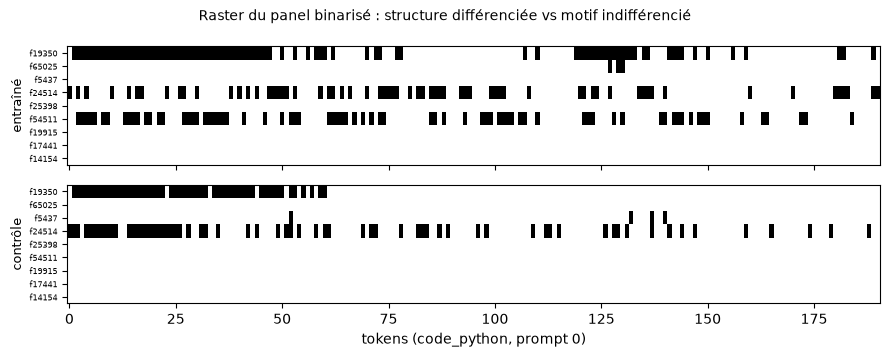

In [8]:
def states_by_set(tr, panel):
    panels = st.acts_topk_panels(tr, panel)
    out = {}
    for s in SETS:
        dense = np.concatenate([panels[(s, i)] for i in range(4)])
        out[s] = st.states_from_panel(st.binarize_quantile(dense))
    return out

states_tr = states_by_set(traces["trained"], panel_final)
states_ct_samepanel = states_by_set(traces["control"], panel_final)

mass_tr = sum(st.densify(e["ids"], e["vals"], panel_final).sum()
              for e in traces["trained"]["prompts"].values())
mass_ct = sum(st.densify(e["ids"], e["vals"], panel_final).sum()
              for e in traces["control"]["prompts"].values())

print(f"{'jeu':>13s} | {'T':>4s} | {'états (entraîné)':>16s} | {'états (contrôle, même panel)':>28s}")
for s in SETS:
    print(f"{s:>13s} | {len(states_tr[s]):>4d} | {len(set(states_tr[s].tolist())):>16d} "
          f"| {len(set(states_ct_samepanel[s].tolist())):>28d}")
print(f"\nmasse d'activation du panel : entraîné = {mass_tr:.0f}, "
      f"contrôle = {mass_ct:.0f} (ratio {mass_tr / max(mass_ct, 1e-9):.1f}x)")
print("=> lecture : la masse est comparable, mais la structure d'états s'effondre. "
      "Le contrôle pousse encore de l'activation dans ces directions, sans la "
      "différenciation temporelle/thématique qui crée les états : c'est la "
      "STRUCTURE, pas la masse, qui est la propriété du modèle entraîné.")

s_demo = "code_python"
p_tr = st.binarize_quantile(st.acts_topk_panels(traces["trained"], panel_final)[(s_demo, 0)])
p_ct = st.binarize_quantile(st.acts_topk_panels(traces["control"], panel_final)[(s_demo, 0)])
fig, axes = plt.subplots(2, 1, figsize=(9, 3.6), sharex=True)
for ax, bits, title in ((axes[0], p_tr, "entraîné"), (axes[1], p_ct, "contrôle")):
    ax.imshow(bits.T, cmap="Greys", aspect="auto", interpolation="nearest")
    ax.set_ylabel(title, fontsize=9)
    ax.set_yticks(range(len(panel_final)))
    ax.set_yticklabels([f"f{f}" for f in panel_final], fontsize=6)
axes[1].set_xlabel(f"tokens ({s_demo}, prompt 0)")
fig.suptitle("Raster du panel binarisé : structure différenciée vs motif indifférencié", fontsize=10)
plt.tight_layout(); plt.show()

## Gate 11 — le substrat S4 est-il *valide* pour le banc ?

Le gate ne demande pas encore un verdict scientifique — il demande la **plomberie** : (a) des comptes d'états/transitions dans la **plage traitable**, (b) `trajectory_battery` qui tourne, (c) un contraste `shuffled_baseline` **non dégénéré** (le contrôle shuffle produit des valeurs distinctes — sinon il ne contraint rien). S4 = le modèle *entraîné* muni du panel validé au Gate 10 : c'est lui qui entre au banc.

**Et le modèle-contrôle ?** Analysé avec ses propres 10 features différentielles, son alphabet d'états **sature** (~200 états distincts sur ~400-650 tokens : un état quasi neuf à chaque pas — nous l'avons mesuré avant d'écrire cette cellule). Or le chemin d'échelles glouton de `emergent_complexity` a un coût qui explose avec la taille de l'alphabet : la batterie complète y est **intraitable par construction**, et c'est précisément le genre de fait que le critère (a) est chargé de détecter et de *rapporter* plutôt que de maquiller. On rapporte donc pour le contrôle : `n_states`/`n_transitions` (le constat de saturation) et un **contraste EI** (information effective, coût O(n²), sans le chemin glouton). La comparaison créditée à alphabet apparié est le travail du **Gate 12 d'ICT-22**.

**Lecture honnête annoncée d'avance** : rien n'oblige les gains de S4 à être crédités ici — et ils ne le seront pas tous. Ce notebook établit que la machinerie tourne et que ses contrastes sont exploitables, pas que S4 « gagne ».

In [9]:
from ict import causal_emergence as CE
from ict import tpm_estimation as TE

# --- S4 (modèle entraîné, panel Gate 10) : batterie complète + 3 gains, 20 shuffles
rng = np.random.default_rng(42)
report, degenerate = [], False
for s in SETS:
    seq = states_tr[s].tolist()
    g = syn.emergence_gain(seq, rng, n_shuffles=20)
    b = syn.trajectory_battery(seq)
    degenerate |= abs(g["ec_real"] - g["ec_shuffled"]) < 1e-9
    report.append((s, b["n_states"], b["n_transitions"], g["ei_real"], g["ec_real"],
                   g["ec_gain"], g["fe_gain"], g["k_gain"], g["credited"]))

print("S4 = entraîné + panel Gate 10 (batterie complète, 20 shuffles) :")
print(f"{'jeu':>13s} | {'états':>5s} | {'trans':>5s} | {'EI':>5s} | {'EC':>5s} "
      f"| {'ec_gain':>7s} | {'fe_gain':>7s} | {'k_gain':>7s} | crédité")
for s, ns, nt, ei, ec, ecg, feg, kg, cred in report:
    print(f"{s:>13s} | {ns:>5d} | {nt:>5d} | {ei:>5.2f} | {ec:>5.2f} "
          f"| {ecg:>+7.3f} | {feg:>+7.3f} | {kg:>+7.3f} | {cred}")

# --- Contrôle (son propre panel) : tractabilité + contraste EI (O(n²), sans EC glouton)
panel_control = st.differential_features(traces["control"], k=10)
states_ct = states_by_set(traces["control"], panel_control)
print("\nContrôle (panel propre) — saturation d'alphabet + contraste EI :")
print(f"{'jeu':>13s} | {'états':>5s} | {'trans':>5s} | {'EI réel':>7s} | {'EI shuffle (moy/5)':>18s}")
ei_degen = False
for s in SETS:
    seq = states_ct[s].tolist()
    tpm, mapping = TE.tpm_from_trajectory(seq)
    ei_real = CE.causal_profile(tpm)["effective_information"]
    eis = []
    for _ in range(5):
        tpm_s, _ = TE.tpm_from_trajectory(syn.shuffle_states(seq, rng))
        eis.append(CE.causal_profile(tpm_s)["effective_information"])
    ei_degen |= abs(ei_real - np.mean(eis)) < 1e-9
    print(f"{s:>13s} | {len(mapping):>5d} | {len(seq) - 1:>5d} | {ei_real:>7.3f} "
          f"| {np.mean(eis):>18.3f}")

max_states_s4 = max(r[1] for r in report)
print(f"\n(a) tractabilité : S4 max n_states = {max_states_s4} (traitable) ; "
      "contrôle ~200 états = alphabet saturé, rapporté tel quel (EC gloutonne hors plage)")
print("(b) trajectory_battery : exécutée sur les 5 jeux de S4 sans erreur")
print(f"(c) contrastes shuffle non dégénérés : S4 ec {'NON' if degenerate else 'OK'}, "
      f"contrôle EI {'NON' if ei_degen else 'OK'}")
assert not degenerate and not ei_degen and max_states_s4 < 512
print("\n=> GATE 11 : PASS — substrat S4 prêt pour le banc. "
      "Le verdict crédité multi-jeux appartient à ICT-22 (Gate 12).")

S4 = entraîné + panel Gate 10 (batterie complète, 20 shuffles) :
          jeu | états | trans |    EI |    EC | ec_gain | fe_gain |  k_gain | crédité
  code_python |    11 |   655 |  1.27 |  5.15 |  -0.304 |  +0.741 |  +0.213 | False
     dialogue |    39 |   571 |  2.82 |  8.47 |  -1.146 |  +0.540 |  +0.029 | False
         math |    12 |   615 |  1.03 |  5.30 |  -0.315 |  +0.537 |  +0.124 | False
 narrative_en |    17 |   370 |  1.46 |  6.29 |  -0.316 |  +0.826 |  +0.100 | False
     prose_fr |    36 |   483 |  2.88 |  9.22 |  -0.110 |  +0.302 |  +0.063 | False

Contrôle (panel propre) — saturation d'alphabet + contraste EI :
          jeu | états | trans | EI réel | EI shuffle (moy/5)
  code_python |   192 |   655 |   5.871 |              5.336
     dialogue |   232 |   571 |   6.471 |              6.256
         math |   223 |   615 |   6.250 |              5.895
 narrative_en |   177 |   370 |   6.222 |              6.153
     prose_fr |   206 |   483 |   6.445 |              6.1

## Lecture honnête des résultats

Trois choses sont établies, une ne l'est pas :

1. **Le panel est réel** (Gate 10) : ses features re-tirent sur leurs concepts sur des prompts jamais vus, avec précision rapportée feature par feature — et celle qui ne se reproduisait pas a été éjectée, pas maquillée.
2. **La structure est une propriété du modèle entraîné — et c'est la structure, pas la masse** : le même panel appliqué au modèle-contrôle garde une masse d'activation comparable (~1,3× d'écart seulement) mais son répertoire d'états s'effondre (39 → 8 sur le dialogue). Le résiduel permuté pousse encore de l'énergie dans ces directions ; ce qui disparaît, c'est la différenciation temporelle et thématique qui fabrique des états distincts. Ce n'est pas un artefact de la binarisation ou du bit-packing — identiques des deux côtés.
3. **La machinerie du banc tourne sur S4** (Gate 11) : TPM traitables, batterie complète sur les 5 jeux, contrastes shuffle exploitables, les trois gains (ec/fe/k) calculés. Et un fait de tractabilité rapporté sans fard : le contrôle, mesuré avec son propre panel, **sature son alphabet d'états** (~200 états distincts, un quasi-nouveau par token) — régime quasi sans mémoire où le chemin d'échelles glouton de l'EC devient intraitable, exactement ce que le critère (a) du gate est chargé de détecter.
4. **Non établi ici** : que S4 présente une complexité intégrée *créditée*. Les `ec_gain` de S4 sont faibles voire négatifs — le shuffle fait parfois aussi bien que la trajectoire réelle sur cette métrique, à cette échelle, avec ce panel. C'est exactement le genre de résultat que la discipline de créditation de la série est faite pour ne pas enjoliver : la question du verdict revient à ICT-22 (Gate 12), avec ses ≥5 jeux de prompts et sa double comparaison shuffle **et** modèle-contrôle à alphabet apparié.

## Exercice 1 — la taille du panel change-t-elle le verdict ?

Le panel de ~9 features est un choix, pas une loi. Un panel plus petit (5) fusionne des états distincts ; un plus grand (15) fragmente la trajectoire en états rares que la TPM n'estime plus bien.

**Objectif** : rejouer la chaîne panel → états → `emergence_gain` pour des panels de taille 5, 10 et 15, et comparer `n_states` et `ec_gain` sur deux jeux de votre choix.

*Indices* : `st.differential_features(train, k=taille)` pour la sélection ; réutilisez `states_by_set` ; gardez `rng = np.random.default_rng(42)` pour la reproductibilité.

In [10]:
# Exercice 1 : effet de la taille du panel
# TODO étudiant :
#  - Étape 1 : pour taille in (5, 10, 15), sélectionner un panel sur `train`
#  - Étape 2 : construire les états par jeu (states_by_set) sur le modèle entraîné
#  - Étape 3 : emergence_gain (n_shuffles=20, graine 42) sur 2 jeux, comparer
#              n_states et ec_gain dans un petit tableau
resultats_ex1 = None  # TODO étudiant
print("Exercice à compléter")

Exercice à compléter


## Exercice 2 — binarisation : quantile vs seuil fixe

`binarize_quantile` seuille chaque feature à la médiane de ses valeurs **positives** (q=0,5). Ce choix est robuste aux échelles très différentes des features, mais il impose ~50 % d'occupation à chaque feature active.

**Objectif** : comparer q ∈ {0,25 ; 0,5 ; 0,75} et un seuil fixe global (par exemple `dense > 1.0`) sur la trajectoire `code_python` du modèle entraîné : nombre d'états, EC réel, `ec_gain`.

*Indices* : le seuil fixe s'écrit en une ligne numpy (`dense > seuil`) puis `st.states_from_panel` ; attention, avec q=0,75 certaines features deviennent presque muettes — regardez `n_states` avant d'interpréter le gain.

In [11]:
# Exercice 2 : sensibilité à la binarisation
# TODO étudiant :
#  - Étape 1 : densifier le panel final sur code_python (4 prompts concaténés)
#  - Étape 2 : binariser avec q=0.25, 0.5, 0.75 puis avec un seuil fixe
#  - Étape 3 : pour chaque variante, états -> emergence_gain -> tableau comparatif
resultats_ex2 = None  # TODO étudiant
print("Exercice à compléter")

Exercice à compléter


## Exercice 3 — une autre couche du flux résiduel (GPU requis)

La couche 16 (sur 32) est un choix médian classique : assez profonde pour des concepts abstraits, assez loin de la sortie pour ne pas être dominée par la prédiction du prochain token. Qwen-Scope publie des SAE pour d'autres couches.

**Objectif** : extraire les traces de la couche 8 (ou 24) et comparer le panel différentiel obtenu à celui de la couche 16 (recouvrement des features ? sélectivités comparables ?).

*Indices* : tout passe par le script CLI — aucune modification de code n'est nécessaire :
```bash
CUDA_VISIBLE_DEVICES=2 python scripts/extract_sae_traces.py --stage full --variant trained --layer 8
```
puis `st.load_traces("traces/ict21_sae_layer8_trained.npz")`. Sans GPU, cet exercice reste au stade du plan d'analyse : écrivez le code qui *consommerait* les traces.

In [12]:
# Exercice 3 : comparaison inter-couches (GPU requis pour l'extraction)
# TODO étudiant :
#  - Étape 1 : extraire la couche 8 via le script CLI (voir markdown ci-dessus)
#  - Étape 2 : charger les deux npz, sélectionner un panel par couche (held-out !)
#  - Étape 3 : mesurer le recouvrement des panels et comparer les sélectivités
recouvrement_couches = None  # TODO étudiant
print("Exercice à compléter")

Exercice à compléter


## Conclusion

Ce notebook a fait entrer un transformer réel dans le banc de la série, sans en trahir les règles :

- **Gate 10 : PASS.** Panel de features différentielles sélectionné sur 12 prompts, vérifié sur 5 prompts held-out, précision rapportée par feature ; la feature non reproductible est sortie du panel, documentée.
- **Gate 11 : PASS.** États et transitions de S4 traitables sur les 5 jeux, batterie complète exécutée, contrastes shuffle non dégénérés (EC sur S4, EI sur le contrôle) ; la saturation d'alphabet du contrôle est rapportée comme fait de tractabilité : **S4 est prêt pour le banc**.
- **Livrables durables** : `traces/ict21_sae_layer16_{trained,control}.npz` (~0,5 Mio chacun, sparse exhaustif — le schéma `acts_topk` K≈64 amendé de #5101 s'en dérive exactement, et le hook de clamp du Gate 24 de #5635 reste possible), `ict/sae_traces.py` (numpy-only, 8 tests), `scripts/extract_sae_traces.py` (GPU confiné).
- **Ce qui n'est pas revendiqué** : un verdict de complexité intégrée créditée sur S4 — c'est ICT-22 (#5102, Gate 12) ; et toute lecture *workspace/ignition* — c'est ICT-24 (#5635, Gates 22-24), qui consommera ces mêmes traces.

La série tient sa ligne : le GPU est un fournisseur de traces, le banc reste numpy-only, et chaque claim passe par un contrôle avant d'être crédité.

## Références

- **Qwen-Scope** : *Scaling Sparse Autoencoders on Qwen3.5* (arXiv:2605.11887) — SAE résiduels top-k publiés pour Qwen3.5-9B-Base (65 536 features, L0_50), convention d'encodage reprise ici.
- **Anthropic** : *A Global Workspace in Claude?* (anthropic.com/research/global-workspace) — J-space jacobien, broadcast structurel, ablation sélective ; voir les garde-fous en tête de notebook.
- **S. Dehaene** : *Consciousness and the Brain* (2014) — global neuronal workspace, ignition ; cadre théorique de la lecture temporelle qu'ICT-24 instrumentera.
- **E. Hoel et al.** : *Quantifying causal emergence* (PNAS 2013) — l'émergence causale macro > micro qui fonde `ec_gain`.
- **Série ICT** : Epic #4588 ; ce notebook = #5101 ; aval : #5102 (ICT-22), #5635 (ICT-24).